# FashionMNIST – Improved CNN
Key improvements over the original:
- **Data augmentation** (random flips + random crop) to reduce overfitting
- **Stronger model** with BatchNorm, more channels, and a Residual block
- **AdamW + OneCycleLR** scheduler → converges in ~10 epochs instead of thousands
- **Early stopping** to avoid wasted compute
- **Larger batch size** (128) for stable gradients
- Clean train/eval loop with per-epoch metrics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm.auto import tqdm

%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

CLASSES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle boot']

Using device: cpu


c:\Users\azerty\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading with Augmentation
Training augmentation: random horizontal flip + small random crop.
Test set uses only normalization (no augmentation).

In [2]:
# FashionMNIST mean/std (computed over training set)
MEAN, STD = (0.2860,), (0.3530,)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_data = torchvision.datasets.FashionMNIST(
    root='data', train=True, download=True, transform=train_transform)
test_data = torchvision.datasets.FashionMNIST(
    root='data', train=False, download=True, transform=test_transform)

BATCH_SIZE = 128

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 469 | Test batches: 79


## 2. Model – ImprovedCNN

Architecture:
- **Block 1**: Conv(1→32) → BN → ReLU → Conv(32→32) → BN → ReLU → MaxPool
- **Block 2**: Conv(32→64) + **residual skip** → BN → ReLU → MaxPool
- **Block 3**: Conv(64→128) → BN → ReLU → Global Average Pool
- **Classifier**: Linear(128→256) → Dropout(0.4) → Linear(256→10)

BatchNorm after every conv stabilizes training and allows higher learning rates.
The residual connection in block 2 helps gradients flow and boosts accuracy.

made by Abdelhamid SAIDI

In [3]:
class ResBlock(nn.Module):
    """Mini residual block: two 3x3 convs with a skip connection."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + x)   # residual skip


class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # ---- Feature extractor ----
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),           # 28 → 14
            nn.Dropout2d(0.1),

            # Block 2 (with residual)
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResBlock(64),
            nn.MaxPool2d(2),           # 14 → 7
            nn.Dropout2d(0.1),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)   # 7×7 → 1×1, robust to size changes

        # ---- Classifier ----
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


model = ImprovedCNN(num_classes=10).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
print(model)

Trainable parameters: 359,466
ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_

## 3. Loss, Optimizer & Scheduler

- **AdamW** (Adam + weight decay) → better generalisation than plain SGD/Adam
- **OneCycleLR** scheduler → ramps up LR then anneals; reaches high accuracy in far fewer epochs

In [4]:
NUM_EPOCHS  = 10      # ← was 1024 / 2048 in the original!
LR_MAX      = 3e-3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # label smoothing helps generalize

optimizer = optim.AdamW(model.parameters(), lr=LR_MAX, weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.3,
)

def accuracy_fn(y_true, y_pred_logits):
    correct = (y_pred_logits.argmax(dim=1) == y_true).sum().item()
    return correct / len(y_true) * 100

## 4. Training Loop with Early Stopping

In [5]:
def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, total_acc = 0.0, 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # gradient clipping
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        total_acc  += accuracy_fn(y, logits)
    return total_loss / len(loader), total_acc / len(loader)


@torch.inference_mode()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc = 0.0, 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        total_loss += criterion(logits, y).item()
        total_acc  += accuracy_fn(y, logits)
    return total_loss / len(loader), total_acc / len(loader)


# ---- Training run with early stopping ----
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc   = 0.0
patience       = 3          # stop if val_acc doesn't improve for 3 consecutive epochs
patience_count = 0

torch.manual_seed(42)

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc='Epochs'):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    vl_loss, vl_acc = eval_epoch(model, test_loader,  criterion, device)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch:02d} | '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}% | '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%')

    # Save best model
    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        patience_count = 0
        torch.save(model.state_dict(), 'best_fashionmnist.pt')
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f'Early stopping at epoch {epoch} (best val acc: {best_val_acc:.2f}%)')
            break

print(f'\n✅ Best Validation Accuracy: {best_val_acc:.2f}%')

Epochs:  10%|█         | 1/10 [02:33<23:01, 153.55s/it]

Epoch 01 | Train Loss: 1.3250  Acc: 63.03% | Val Loss: 0.9393  Acc: 79.47%


Epochs:  20%|██        | 2/10 [04:57<19:43, 147.99s/it]

Epoch 02 | Train Loss: 0.9246  Acc: 81.39% | Val Loss: 0.8960  Acc: 82.15%


Epochs:  30%|███       | 3/10 [07:14<16:40, 142.95s/it]

...

Epoch 08 | Train Loss: 0.6924  Acc: 92.00% | Val Loss: 0.6680  Acc: 92.73%


Epochs:  90%|█████████ | 9/10 [21:17<02:19, 139.75s/it]

Epoch 09 | Train Loss: 0.6775  Acc: 92.66% | Val Loss: 0.6579  Acc: 92.99%


Epochs: 100%|██████████| 10/10 [23:32<00:00, 141.20s/it]

Epoch 10 | Train Loss: 0.6716  Acc: 92.97% | Val Loss: 0.6553  Acc: 93.15%

✅ Best Validation Accuracy: 93.15%


## 5. Training Curves

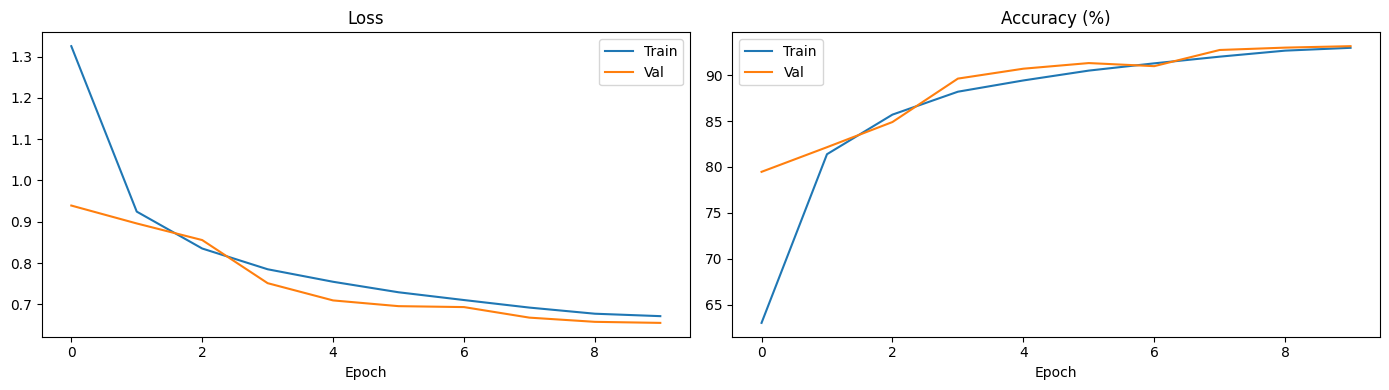

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.show()

## 6. Load Best Model & Final Evaluation

In [7]:
# Load the checkpoint with the best validation accuracy
model.load_state_dict(torch.load('best_fashionmnist.pt', map_location=device))

y_preds, y_true = [], []
model.eval()
with torch.inference_mode():
    for X, y in tqdm(test_loader, desc='Evaluating'):
        X = X.to(device)
        preds = model(X).argmax(dim=1).cpu()
        y_preds.append(preds)
        y_true.append(y)

y_preds = torch.cat(y_preds)
y_true  = torch.cat(y_true)

print(classification_report(y_true, y_preds, target_names=CLASSES))

Evaluating: 100%|██████████| 79/79 [00:12<00:00,  6.33it/s]


              precision    recall  f1-score   support

 T-shirt/top       0.89      0.88      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.92      0.91      0.91      1000
       Dress       0.93      0.93      0.93      1000
        Coat       0.88      0.92      0.90      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.81      0.78      0.79      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



## 7. Confusion Matrix

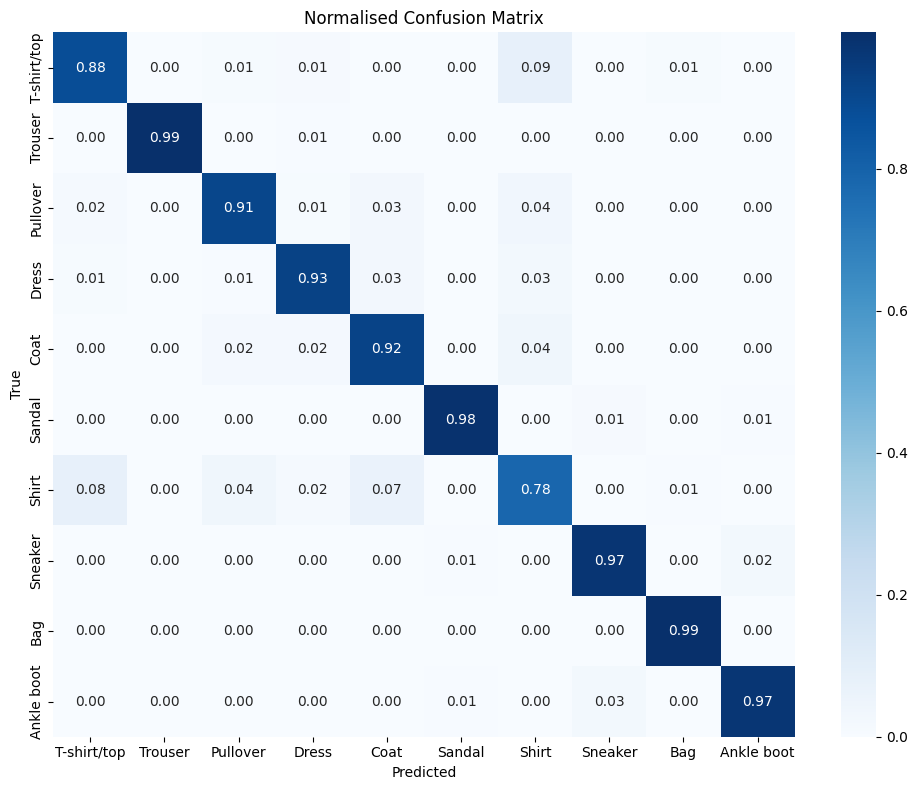

In [ ]:
cm = confusion_matrix(y_true, y_preds, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Normalised Confusion Matrix')
plt.tight_layout()
plt.show()
#made by Abdelhamid SAIDI

## 8. Visualise Predictions on Random Test Samples

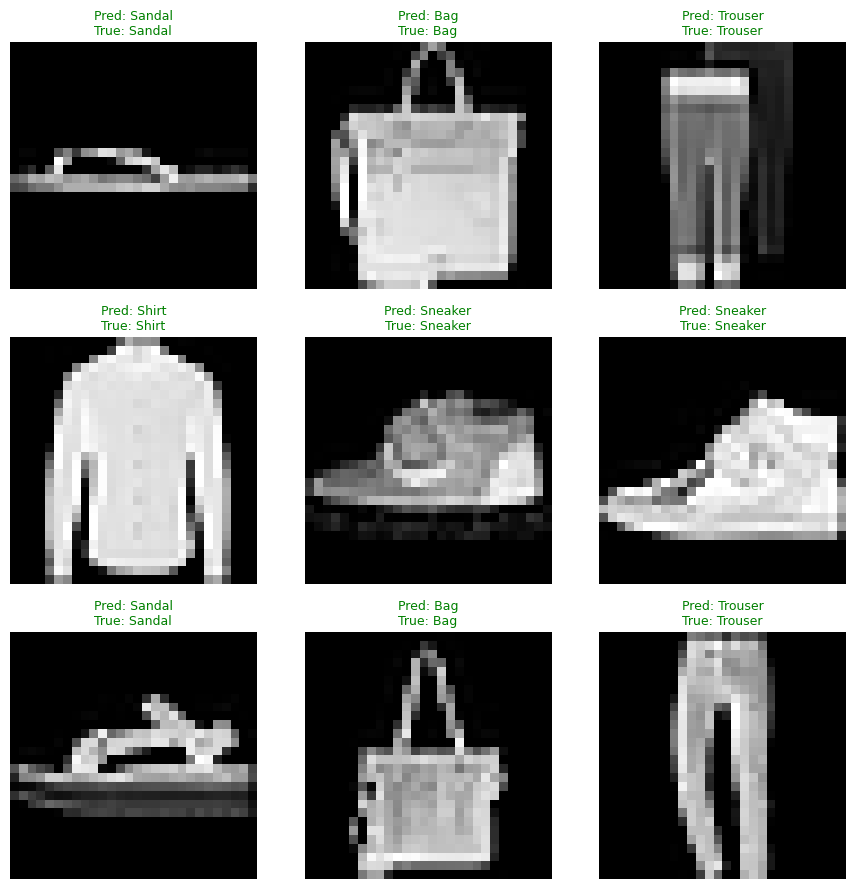

In [9]:
import random
random.seed(0)
n = 9
idxs = random.sample(range(len(test_data)), n)

model.eval()
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
with torch.inference_mode():
    for ax, idx in zip(axes.flat, idxs):
        img, true_lbl = test_data[idx]
        logit = model(img.unsqueeze(0).to(device))
        pred_lbl = logit.argmax(dim=1).item()
        ax.imshow(img.squeeze(), cmap='gray')
        color = 'green' if pred_lbl == true_lbl else 'red'
        ax.set_title(f'Pred: {CLASSES[pred_lbl]}\nTrue: {CLASSES[true_lbl]}',
                     color=color, fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.show()